# Variant Effect Prediction Pipeline

This notebook demonstrates how to use the `variant-effect-prediction` toolkit
to analyze the functional impact of genomic variants using sequence-to-function models.

The pipeline consists of:

1. Loading variants from a VCF
2. Filtering variants to SNVs
3. Extracting reference and alternate sequences
4. Predicting model outputs for ref/alt alleles
5. Computing effect sizes
6. Estimating statistical significance by marginalization
7. Visualizing variant effects genome-wide

This workflow is designed to support large sequence models such as:

- Borzoi
- Enformer
- Basenji

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from vcf_utils import (
    parse_vcf,
    filter_variants,
    filter_to_snvs,
    variants_to_intervals,
)

from prediction import (
    predict_variant_effects,
    marginalize_variants,
)

from analysis import (
    rank_variants,
    summarize_effects,
    plot_manhattan,
)

/home/jsdearbo/.local/lib/python3.10/site-packages/tangermeme/ersatz.py:472: NumbaDeprecationWarning: The keyword argument 'nopython=False' was supplied. From Numba 0.59.0 the default is being changed to True and use of 'nopython=False' will raise a warning as the argument will have no effect. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit(params, nopython=False, cache=True)


Ordinarily, we would load a sequence-to-function model and call input sequnces by chromosome coordinates from a reference fasta.

For the purposes fo this demo, we'll use a simple dummy model and synthetic sequences.

In [2]:
import numpy as np

def synthetic_ref_alt_seqs(chrom, pos, ref, alt, genome_fasta=None, seq_len=1000):
    """
    Synthetic sequence generator for demo notebooks.
    Mimics variant_to_ref_alt_seqs without requiring a genome FASTA.
    """

    bases = np.array(list("ACGT"))

    seq = np.random.choice(bases, seq_len)

    center = seq_len // 2
    seq[center] = ref

    ref_seq = "".join(seq)

    alt_seq_arr = seq.copy()
    alt_seq_arr[center] = alt
    alt_seq = "".join(alt_seq_arr)

    return ref_seq, alt_seq

In [3]:
import torch
import torch.nn as nn

# toy model for demo purposes
class DemoSequenceModel(nn.Module):
    """
    Small toy model that mimics a sequence-to-function predictor.
    Input: one-hot encoded DNA [B,4,L]
    Output: regulatory signal track [B,L]
    """

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(4, 32, kernel_size=15, padding=7),
            nn.GELU(),
            nn.Conv1d(32, 32, kernel_size=15, padding=7),
            nn.GELU(),
            nn.Conv1d(32, 1, kernel_size=1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

    def predict_on_seqs(self, seqs, device="cpu"):
        """
        Fake model: returns signal proportional to GC content.
        """

        preds = []

        for seq in seqs:
            gc = (seq.count("G") + seq.count("C")) / len(seq)
            preds.append([gc])

        return np.array(preds)

model = DemoSequenceModel()
model.eval()

print("Demo model ready.")

Demo model ready.


The toolkit supports filtering by:

- allele composition
- insertion/deletion length
- variant quality
- SNV restriction

Here we restrict to **single-nucleotide variants** for compatibility with most sequence models.

In [4]:
# load example VCF file (small synthetic dataset for demonstration)
variants = pd.DataFrame(
    {
        "chrom": ["chr1", "chr1", "chr1"],
        "pos": [1550000, 1560000, 1570000],
        "ref": ["A", "C", "T"],
        "alt": ["G", "T", "C"],
        "id": ["var1", "var2", "var3"],
    }
)

variants

,chrom,pos,ref,alt,id
0,chr1,1550000,A,G,var1
1,chr1,1560000,C,T,var2
2,chr1,1570000,T,C,var3


In [5]:
# filter variants to SNVs with standard bases only
variants = filter_variants(
    variants,
    standard_bases=True,
    max_insert_len=0,
    max_del_len=0,
)

# further filter to SNVs only
variants = filter_to_snvs(variants)

print(f"{len(variants)} variants after filtering")

3 variants after filtering


Each variant is centered inside a large genomic window so the model
can capture long-range regulatory context.

For pipeline demonstration purposes, we'll use a small dummy model.

The model prediction is computed for:

reference sequence  
alternate sequence  

Effect size is computed as:

log2FC = log2( prediction_alt / prediction_ref )

In [ ]:
# predict variant effects
effects = predict_variant_effects(
    variants,
    model=model,          # pretrained Borzoi / Enformer
    #genome="hg38",
    seq_len=1024,
    compare_func="log2fc",
    sequence_provider=synthetic_ref_alt_seqs,  # use synthetic sequence generator
)

print(effects.head())

  chrom      pos ref alt    id  effect_size
0  chr1  1550000   A   G  var1     0.002877
1  chr1  1560000   C   T  var2    -0.002860
2  chr1  1570000   T   C  var3     0.002756


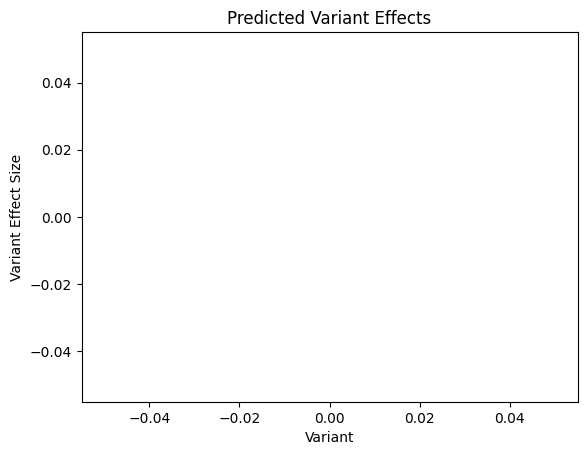

In [7]:
plt.bar(range(len(effects)), effects["effect_size"])
plt.ylabel("Variant Effect Size")
plt.xlabel("Variant")
plt.title("Predicted Variant Effects")
plt.show()